In [1]:
# Problem 4 on Homework 2

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
from scipy.stats import skew
from scipy.stats import norm

In [140]:
rng = np.random.default_rng(seed=10)
delta_t = .005
t_vals = np.linspace(0,5000, int(5000/delta_t))
tau = 20
nu = [.1, 1, 10]
w = [5, .5, .05]

burn_in_idx = int(100/delta_t)

In [55]:
spikes_prob = rng.uniform(size = len(t_vals))
spikes = spikes_prob < nu*delta_t

In [71]:
voltage = np.zeros(len(t_vals))

for idx in range(len(t_vals)):
    if spikes[idx] == True:
        # there was a spike in this interval
        before_idx = np.zeros(idx)

        adj_t = t_vals[0:(len(t_vals)-idx)]
        after_idx = w*np.e**(-adj_t/tau)
        voltage = voltage + np.concatenate((before_idx, after_idx))

In [142]:
for p in range(3):
    rng = np.random.default_rng(seed=10)
    nu_val = nu[p]
    w_val = w[p]
    # simulate spikes
    spikes_prob = rng.uniform(size = len(t_vals))
    spikes = spikes_prob < nu_val*delta_t

    # calculate voltage 
    voltage = np.zeros(len(t_vals))

    for idx in range(len(t_vals)):
        if spikes[idx] == True:
            # there was a spike in this interval
            before_idx = np.zeros(idx)
            
            # calculate effect of the spike on all time intervals after it
            adj_t = t_vals[0:(len(t_vals)-idx)]
            after_idx = w_val*np.e**(-adj_t/tau)
            voltage = voltage + np.concatenate((before_idx, after_idx))

    # report mean and variance after throwing out the first bit of time
    voltage_burned_in = voltage[burn_in_idx:]

    print("Info for simulation", p+1)
    print("Mean of process", np.mean(voltage_burned_in))
    print("Variance of process", np.var(voltage_burned_in))
    print("Skew", skew(voltage_burned_in, bias = False))

Info for simulation 1
Mean of process 9.697668387456357
Variance of process 21.86568110809731
Skew 0.8139892831998878
Info for simulation 2
Mean of process 9.931157086010058
Variance of process 2.2890750708520105
Skew 0.13079734983233074
Info for simulation 3
Mean of process 9.9805210334541
Variance of process 0.24306337729300861
Skew 0.09753333031258785


In [148]:
results = pd.DataFrame({
    "tau": [20, 20, 20],
    "nu": [.1, 1, 10],
    "omega": [5, .5, .05],
    "measured_mean": [9.698, 9.931, 9.981],
    "measured_variance": [21.865, 2.289, 0.243],
    "measured_skew": [0.814, 0.131, 0.0975],
    "theoretical_mean": [10, 10, 10],
    "theoretical_variance": [25, 2.5, .25],
    "theoretical_skew": [2/3, .2108185107, 2/30]
})

results

,tau,nu,omega,measured_mean,measured_variance,measured_skew,theoretical_mean,theoretical_variance,theoretical_skew
0,20,0.1,5.00,9.698,21.865,0.8140,10,25.00,0.666667
1,20,1.0,0.50,9.931,2.289,0.1310,10,2.50,0.210819
2,20,10.0,0.05,9.981,0.243,0.0975,10,0.25,0.066667


In [160]:
# save results for nu*tau = 2 and nu*tau = 200

voltage_200 = voltage_burned_in

rng = np.random.default_rng(seed=10)
nu_val = .1
w_val = 5
# simulate spikes
spikes_prob = rng.uniform(size = len(t_vals))
spikes = spikes_prob < nu_val*delta_t

# calculate voltage 
v_2 = np.zeros(len(t_vals))

for idx in range(len(t_vals)):
    if spikes[idx] == True:
        # there was a spike in this interval
        before_idx = np.zeros(idx)
            
        # calculate effect of the spike on all time intervals after it
        adj_t = t_vals[0:(len(t_vals)-idx)]
        after_idx = w_val*np.e**(-adj_t/tau)
        v_2 = v_2 + np.concatenate((before_idx, after_idx))

    # report mean and variance after throwing out the first bit of time
    voltage_2 = v_2[burn_in_idx:]




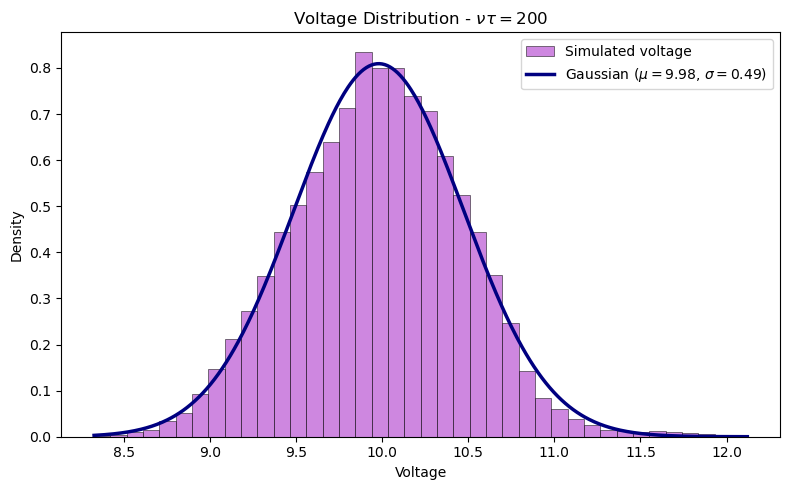

In [192]:
# Calculate mean and standard deviation
mu_200 = np.mean(voltage_200)
sigma_200 = np.std(voltage_200)

# Set up x-values for Gaussian
x = np.linspace(min(voltage_200), max(voltage_200), 500)
gaussian = norm.pdf(x, mu_200, sigma_200)

# Plot
plt.figure(figsize=(8, 5))

plt.hist(
    voltage_200,
    bins=40,
    density=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    label="Simulated voltage",
    color = "mediumorchid"
)

plt.plot(
    x,
    gaussian,
    linewidth=2.5,
    color = "navy",
    label=f"Gaussian ($\\mu={mu_200:.2f}$, $\\sigma={sigma_200:.2f}$)"
)

plt.xlabel("Voltage")
plt.ylabel("Density")
plt.title(r"Voltage Distribution - $\nu \tau = 200$")
plt.legend()
plt.tight_layout()
plt.savefig("voltage_200_plot", dpi=300, bbox_inches="tight")
plt.show()

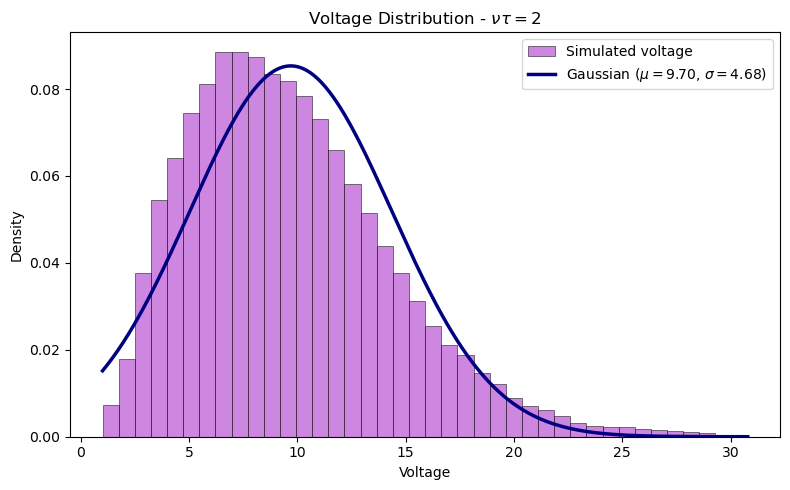

In [190]:
# Calculate mean and standard deviation
mu_2 = np.mean(voltage_2)
sigma_2 = np.std(voltage_2)

# Set up x-values for Gaussian
x = np.linspace(min(voltage_2), max(voltage_2), 500)
gaussian = norm.pdf(x, mu_2, sigma_2)

# Plot
plt.figure(figsize=(8, 5))

plt.hist(
    voltage_2,
    bins=40,
    density=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
    label="Simulated voltage",
    color = "mediumorchid"
)

plt.plot(
    x,
    gaussian,
    linewidth=2.5,
    color = "navy",
    label=f"Gaussian ($\\mu={mu_2:.2f}$, $\\sigma={sigma_2:.2f}$)"
)

plt.xlabel("Voltage")
plt.ylabel("Density")
plt.title(r"Voltage Distribution - $\nu \tau = 2$")
plt.legend()
plt.tight_layout()
plt.savefig("voltage_2_plot", dpi=300, bbox_inches="tight")
plt.show()